<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Semana13/RandomForest_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,1,0,1
1,1,1,38.000000,1,0,71.2833,0,0,0
2,1,3,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,1
5,0,3,29.699118,0,0,8.4583,1,1,0
6,0,1,54.000000,0,0,51.8625,1,0,1
7,0,3,2.000000,3,1,21.0750,1,0,1
8,1,3,27.000000,0,2,11.1333,0,0,1
9,1,2,14.000000,1,0,30.0708,0,0,0


--- DESEMPENHO DO MODELO ---
Acurácia da Floresta: 79.33%

Relatório Detalhado:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



/tmp/ipykernel_686/42686248.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia (%)', y='Variável', data=df_importancia, palette='viridis')


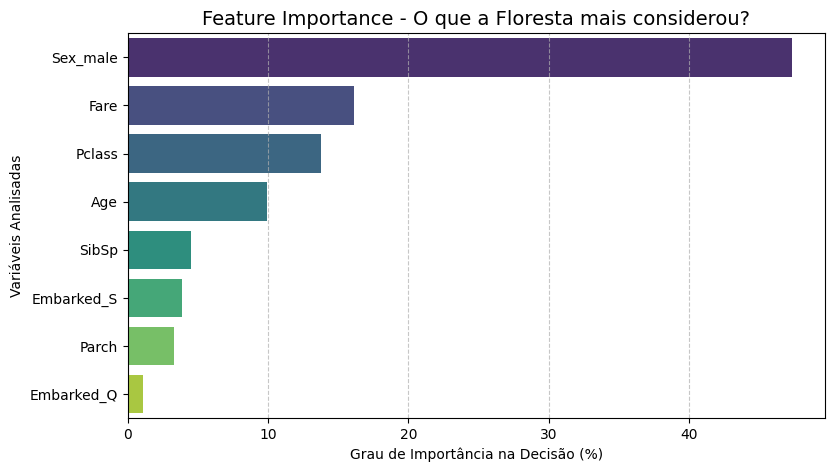

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. Carregando dados (Exemplo: Dataset do Titanic para prever Sobrevivência)
# Substitua pela sua base de dados na hora da aula!
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Pré-processamento rápido para a aula rodar sem erros
df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked']]
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Handle missing values in 'Embarked' before one-hot encoding
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Apply one-hot encoding to 'Sex' and 'Embarked' columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

display(df.head(10))

X = df.drop('Survived', axis=1)
y = df['Survived']

# 2. OBRIGATÓRIO: Divisão de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplicar SMOTE para balanceamento da classe minoritária no conjunto de treino
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Treinando a Floresta
# n_estimators = 100 (Vamos criar uma junta médica com 100 árvores)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_rf.fit(X_train_res, y_train_res)

# 4. Avaliando o Modelo
previsoes = modelo_rf.predict(X_test)
print("--- DESEMPENHO DO MODELO ---")
print(f"Acurácia da Floresta: {accuracy_score(y_test, previsoes) * 100:.2f}%\n")
print("Relatório Detalhado:\n", classification_report(y_test, previsoes))

# 5. O Pulo do Gato: Feature Importance (O que mais impactou a decisão?)
importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    'Variável': X.columns,
    'Importancia (%)': importancias * 100
})

# Ordenar do mais importante para o menos importante
df_importancia = df_importancia.sort_values(by='Importancia (%)', ascending=False)

# 6. Visualização Gráfica para Negócios
plt.figure(figsize=(9, 5))
sns.barplot(x='Importancia (%)', y='Variável', data=df_importancia, palette='viridis')
plt.title('Feature Importance - O que a Floresta mais considerou?', fontsize=14)
plt.xlabel('Grau de Importância na Decisão (%)')
plt.ylabel('Variáveis Analisadas')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Perform label encoding on the 'Sex' column

# Display the value counts after encoding to verify
display(df['Embarked'].value_counts())


,count
Embarked,
S,644
C,168
Q,77


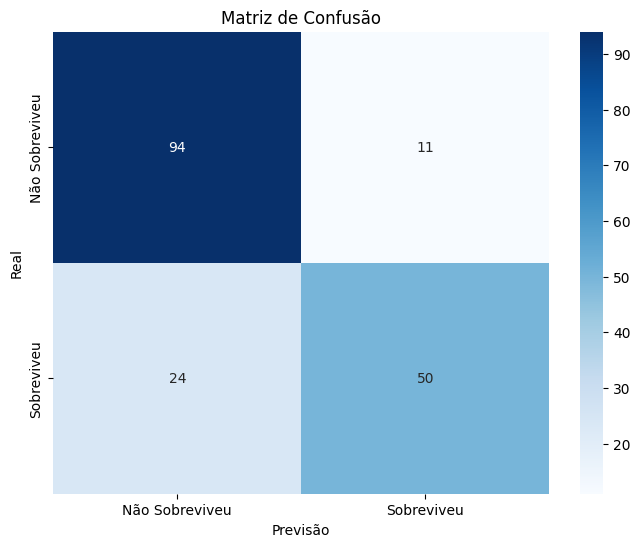

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, previsoes)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()